# Project 2: Fraud Detection - Step 2: Anomaly Detection Models

This notebook trains unsupervised and semi-supervised anomaly detection algorithms to identify suspicious transactions.

## Blueprint Actions Covered
* **Algorithms**: Isolation Forest, One-Class SVM, and Local Outlier Factor (LOF).

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

## 1. Load Preprocessed Datasets

We load the Standard Scaled features and target variables generated in Step 1.

In [2]:
OUTPUT_DIR = "outputs"

X_train = pd.read_csv(os.path.join(OUTPUT_DIR, "train_scaled_std.csv"))
X_val = pd.read_csv(os.path.join(OUTPUT_DIR, "val_scaled_std.csv"))
X_test = pd.read_csv(os.path.join(OUTPUT_DIR, "test_scaled_std.csv"))

y_train = pd.read_csv(os.path.join(OUTPUT_DIR, "y_train.csv")).values.ravel()
y_val = pd.read_csv(os.path.join(OUTPUT_DIR, "y_val.csv")).values.ravel()
y_test = pd.read_csv(os.path.join(OUTPUT_DIR, "y_test.csv")).values.ravel()

print(f"Train shapes:      X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation shapes: X = {X_val.shape}, y = {y_val.shape}")
print(f"Test shapes:       X = {X_test.shape}, y = {y_test.shape}")

Train shapes:      X = (7000, 11), y = (7000,)
Validation shapes: X = (1500, 11), y = (1500,)
Test shapes:       X = (1500, 11), y = (1500,)


## 2. Semi-Supervised Data Filtering

In financial anomaly detection, we want our models to learn the clean baseline of normal (non-fraudulent) transactions. Therefore, we fit our estimators *only* on normal transactions (`is_fraud == 0`) in the training partition, while validating and testing on the full datasets.

In [3]:
# Filter training features to contain only normal transactions
X_train_normal = X_train[y_train == 0]
print(f"Filtered normal train set shape: {X_train_normal.shape} (Original train set had {X_train.shape[0]} samples)")

Filtered normal train set shape: (6894, 11) (Original train set had 7000 samples)


## 3. Model Training

We train three classical anomaly detection models:
1. **Isolation Forest**: Fits a set of isolation trees. Anomalies isolate faster and have shorter path lengths.
2. **One-Class SVM**: Fits a hyperplane dividing normal transaction points from the origin in RBF latent space.
3. **Local Outlier Factor (LOF)**: Computes local density deviations. We fit in `novelty=True` mode to allow testing on validation and test data.

In [4]:
# Define the expected contamination rate based on empirical training class balance
fraud_rate = np.mean(y_train)
print(f"Empirical fraud rate in training partition: {fraud_rate:.4%}")

# 1. Isolation Forest
print("\nTraining Isolation Forest...")
iforest = IsolationForest(contamination=fraud_rate, random_state=42, n_jobs=-1)
iforest.fit(X_train_normal)

# 2. One-Class SVM
print("Training One-Class SVM...")
ocsvm = OneClassSVM(kernel='rbf', nu=fraud_rate, gamma='scale')
ocsvm.fit(X_train_normal)

# 3. Local Outlier Factor
print("Training Local Outlier Factor...")
lof = LocalOutlierFactor(contamination=fraud_rate, novelty=True, n_jobs=-1)
lof.fit(X_train_normal)

print("\nAll models trained successfully.")

Empirical fraud rate in training partition: 1.5143%

Training Isolation Forest...


Training One-Class SVM...
Training Local Outlier Factor...



All models trained successfully.


## 4. Evaluation and Mapping Logic

Standard Scikit-Learn anomaly detection models predict `1` for inliers and `-1` for outliers. We define a helper function to map these to standard binary outputs (`0` = normal, `1` = fraud) and compute anomaly decision scores (negating the decision function so that larger values indicate higher fraud probability).

In [5]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

def evaluate_anomaly_model(model, X, y_true):
    # Predict anomaly labels: 1 = inlier, -1 = outlier
    preds_raw = model.predict(X)
    # Map: 1 -> 0 (normal), -1 -> 1 (fraud)
    y_pred = np.where(preds_raw == 1, 0, 1)
    
    # Anomaly scores: higher score means more anomalous
    # decision_function returns negative anomaly scores (lower is more anomalous)
    # Therefore, we negate it so that larger values indicate higher anomaly
    anomaly_scores = -model.decision_function(X)
    
    metrics = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, anomaly_scores),
        'pr_auc': average_precision_score(y_true, anomaly_scores),
        'y_pred': y_pred,
        'anomaly_scores': anomaly_scores
    }
    return metrics

## 5. Model Validation & Leaderboard

In [6]:
models = {
    'Isolation Forest': iforest,
    'One-Class SVM': ocsvm,
    'Local Outlier Factor': lof
}

results = {}
for name, model in models.items():
    results[name] = evaluate_anomaly_model(model, X_val, y_val)
    
leaderboard_df = pd.DataFrame({
    name: {
        'F1-Score': results[name]['f1'],
        'Precision': results[name]['precision'],
        'Recall': results[name]['recall'],
        'ROC-AUC': results[name]['roc_auc'],
        'PR-AUC': results[name]['pr_auc']
    } for name in models
}).T

print("Validation Leaderboard:")
print(leaderboard_df.round(4))

Validation Leaderboard:
                      F1-Score  Precision  Recall  ROC-AUC  PR-AUC
Isolation Forest        0.3077     0.2381  0.4348   0.9462  0.2494
One-Class SVM           0.1935     0.1538  0.2609   0.9338  0.2026
Local Outlier Factor    0.3333     0.2703  0.4348   0.9587  0.4058


/home/ikartiksavaliya/Desktop/Portfolio projects/ML/omni-retail-customer-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/home/ikartiksavaliya/Desktop/Portfolio projects/ML/omni-retail-customer-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


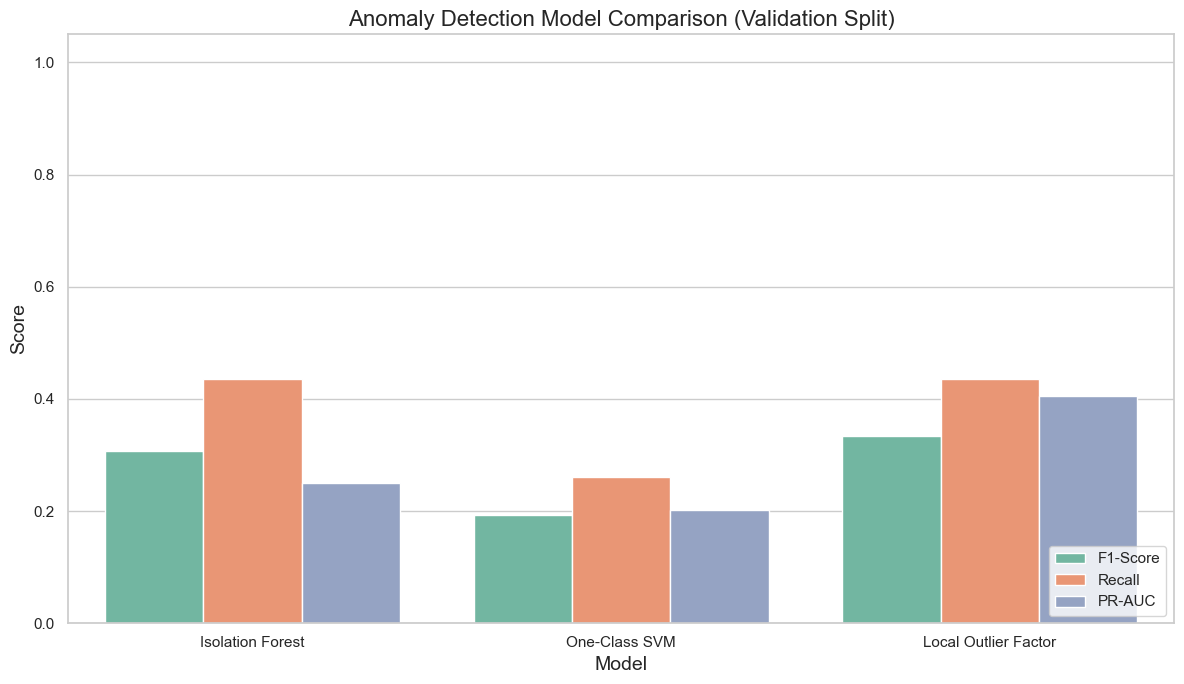

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

# Melt data for plotting
plot_df = leaderboard_df.reset_index().rename(columns={'index': 'Model'})
plot_df = pd.melt(plot_df, id_vars=['Model'], value_vars=['F1-Score', 'Recall', 'PR-AUC'], 
                    var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x='Model', y='Value', hue='Metric', palette='Set2')
plt.title('Anomaly Detection Model Comparison (Validation Split)')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "02_anomaly_leaderboard.png"), dpi=150)
plt.show()

## 6. Test Set Evaluation

We select the best performing model on the validation split (based on F1-Score) and evaluate it on our unseen test dataset.

In [8]:
# Determine best model
best_model_name = leaderboard_df['F1-Score'].idxmax()
print(f"Best Model Selected: {best_model_name}")

best_model = models[best_model_name]
test_metrics = evaluate_anomaly_model(best_model, X_test, y_test)

print(f"\nTest Set Performance for {best_model_name}:")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-Score:  {test_metrics['f1']:.4f}")
print(f"ROC-AUC:   {test_metrics['roc_auc']:.4f}")
print(f"PR-AUC:    {test_metrics['pr_auc']:.4f}")

Best Model Selected: Local Outlier Factor

Test Set Performance for Local Outlier Factor:
Precision: 0.2903
Recall:    0.4091
F1-Score:  0.3396
ROC-AUC:   0.9571
PR-AUC:    0.3757


/home/ikartiksavaliya/Desktop/Portfolio projects/ML/omni-retail-customer-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/home/ikartiksavaliya/Desktop/Portfolio projects/ML/omni-retail-customer-analysis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


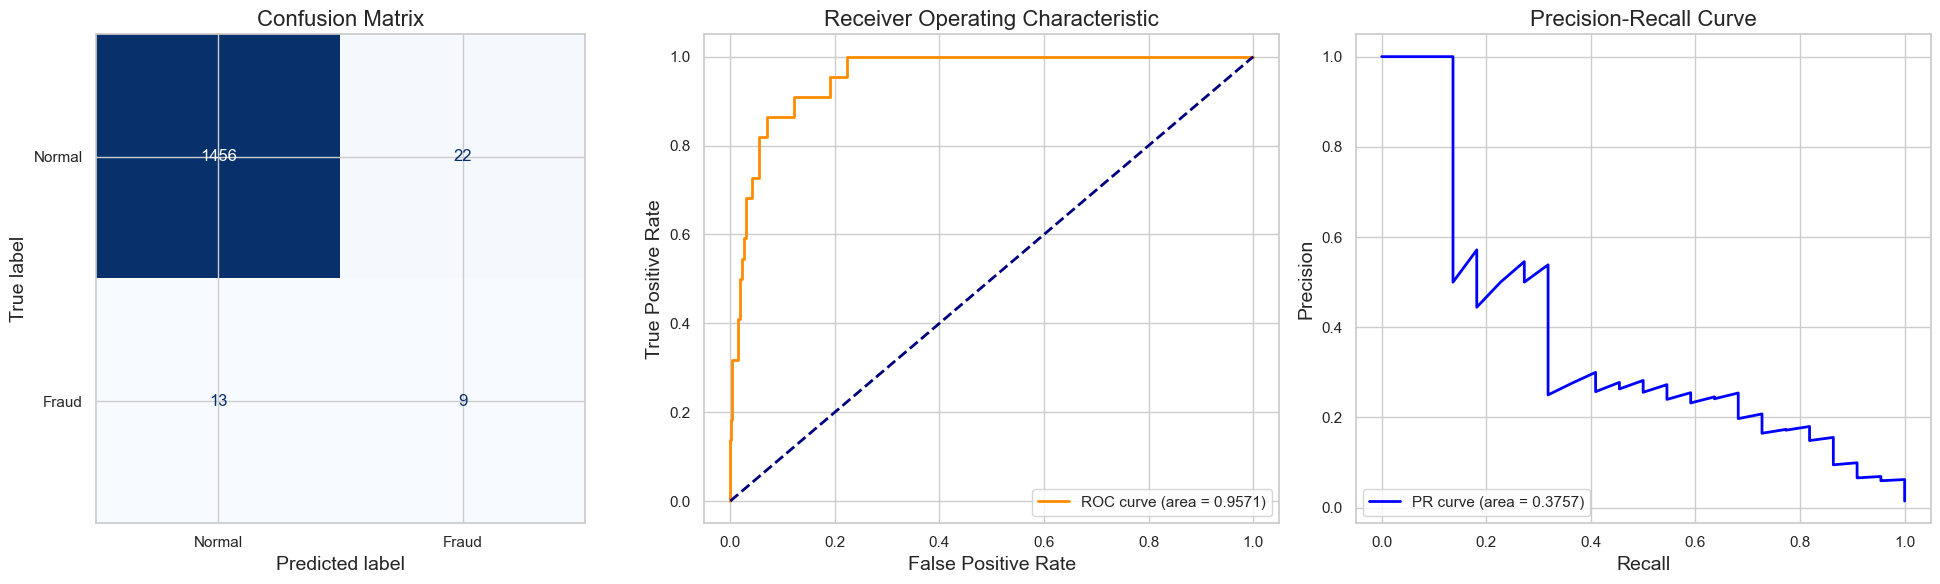

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, test_metrics['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_metrics['anomaly_scores'])
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {test_metrics["roc_auc"]:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, test_metrics['anomaly_scores'])
axes[2].plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {test_metrics["pr_auc"]:.4f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "02_best_anomaly_evaluation.png"), dpi=150)
plt.show()

## 7. Model Serialization

We serialize the best performing anomaly detection model to disk.

In [10]:
import joblib

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

model_payload = {
    'model_name': best_model_name,
    'model': best_model,
    'test_metrics': {
        'precision': test_metrics['precision'],
        'recall': test_metrics['recall'],
        'f1': test_metrics['f1'],
        'roc_auc': test_metrics['roc_auc'],
        'pr_auc': test_metrics['pr_auc']
    }
}
joblib.dump(model_payload, os.path.join(MODELS_DIR, "anomaly_detector.joblib"))
print(f"Best model ({best_model_name}) serialized to models/anomaly_detector.joblib successfully.")

Best model (Local Outlier Factor) serialized to models/anomaly_detector.joblib successfully.
